## Exploring Regression and Feature Engineering for Housing Prices Prediction
### 1. Project Overview
 This project explores regression techniques for predicting residential housing prices in Cook County, Illinois. The dataset collected from the [Cook County Assessor's Office](www.housingstudies.org) contains over 500,000 property records with 61 features such as physical characteristics and geographic information. It builds predictive models using linear regression techniques covered in class, systematically comparing simple and complex feature sets to understand the tradeoffs between model complexity and performance.

### 2. Exploratory Data Analysis and Data Cleaning

**Sale Price Distribution Challenge**
<img src="before.png" width="300" height="150">
Initial examination revealed severe right-skewness in sale prices, making it difficult to interpret the distribution accurately and may obscure important details. Therefore, I applied log transformation and filtered out the outliers that are < $500:

```python
training_data = initial_data[initial_data['Sale Price'] >= 500].copy()
training_data['Log Sale Price'] = np.log1p(training_data['Sale Price'])
```

<img src="distribution.png" width="300" height="150">

**Building Size Analysis**

I then created `Log Building Square Feet` feature and examined correlation with target variable. The jointplot reveals strong positive correlation, indicating building size will be a valuable predictor.

```python
training_data['Log Building Square Feet'] = np.log1p(training_data['Building Square Feet'])
```
<img src="size.png" width="300" height="150">


### 3. Feature Engineering

**Bedroom Extraction**

The original dataset lacks a direct "Bedrooms" column—this information is embedded in text descriptions. For example, "The total number of rooms inside the property." To solve it, I write relative function.

```python
def add_total_bedrooms(data):
    with_rooms = data.copy()
    with_rooms['Bedrooms'] = pd.to_numeric(
        with_rooms['Description'].str.extract(r"(\d+) of which are bedrooms", expand=False)
        .replace(np.nan, "0")
    )
    return with_rooms
```

<img src="violin.png" width="300" height="150">
Violin plot analysis confirms positive association between bedrooms and price, though the effect plateaus after 4-5 bedrooms.

**Neighborhood Aggregation**

There are 193 unique neighborhood codes in total and it may cause severe overfitting. To solve the problem, I assign the variable `in_top_20_neighborhoods` that has been filtered to only contain rows corresponding to properties that are in one of the top 20 most populous neighborhoods.

```python
top_20_neighborhood_codes = training_data['Neighborhood Code'].value_counts().head(20).index.tolist()
in_top_20_neighborhoods = training_data[training_data['Neighborhood Code'].isin(top_20_neighborhood_codes)]

plot_categorical(neighborhoods=in_top_20_neighborhoods)
```
<img src="category.png" width="300" height="150">
According to the category plot, there is much less data available for some neighborhoods. For example, Neighborhood 71 has only around 27% of the number of datapoints as Neighborhood 30. As a result, I create binary "expensive neighborhood" indicator:

```python
def find_expensive_neighborhoods(data, n=3, metric=np.median):
    neighborhood_prices = data.groupby('Neighborhood Code')['Log Sale Price'].apply(metric)
    neighborhoods = neighborhood_prices.nlargest(n).index
    return [int(code) for code in neighborhoods]

expensive_neighborhoods = find_expensive_neighborhoods(training_data, n=3)
training_data['in_expensive_neighborhood'] = training_data['Neighborhood Code'].isin(
    expensive_neighborhoods
).astype(int)
```

**Categorical Variable Encoding**

The Assessor's Office uses the following mapping for the numerical values in the `Roof Material` column.
```
Roof Material (Nominal): 

       1    Shingle/Asphalt
       2    Tar & Gravel
       3    Slate
       4    Shake
       5    Tile
       6    Other
```
However, I found that simply replacing the integers with the appropriate strings isn’t enough. Since `Roof Material` is a categorical variable, I have to one-hot-encode the data. 
```python
from sklearn.preprocessing import OneHotEncoder
def ohe_roof_material(data):
    encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
    roof_material_ohe = encoder.fit_transform(data[['Roof Material']])
    roof_material_names = encoder.get_feature_names_out(['Roof Material'])
    roof_material_df = pd.DataFrame(roof_material_ohe, columns=roof_material_names)
    new_data = pd.concat([data, roof_material_df], axis=1)
    return new_data
```

<img src="ohe.png" width="500" height="200">

**Feature Engineering Pipeline**

I would like to use function that add features to the dataset instead of calling them manually one by one each time. In this way, defining and using a pipeline reduces all the feature engineering to just one function call and ensures that the same transformations are applied to all data.

```python
def feature_engine_pipe(data, pipeline_functions, prediction_col):
    for function, arguments, keyword_arguments in pipeline_functions:
        if keyword_arguments and (not arguments):
            data = data.pipe(function, **keyword_arguments)
        elif (not keyword_arguments) and arguments:
            data = data.pipe(function, *arguments)
        else:
            data = data.pipe(function)
    
    X = data.drop(columns=[prediction_col])
    Y = data.loc[:, prediction_col]
    return X, Y
```


### 4. Model Building and Evaluation

**Fitting a Simple Model**

I split the dataset into a training set and a validation set, letting `train` contain 80% of the data when `validation` contain the remaining 20%. I use the training set to fit my model's parameters and the validation set to evaluate how well my model will perform on unseen data drawn from the same distribution. 

```python
def train_val_split(data):
    data_len = data.shape[0]
    shuffled_indices = np.random.permutation(data_len)
    split_index = int(0.8 * data_len)
    
    train_indices = shuffled_indices[:split_index]
    validation_indices = shuffled_indices[split_index:]
    train = data.iloc[train_indices]
    validation = data.iloc[validation_indices]

    return train, validation
```

I first fit my linear regression model using the ordinary least squares estimator. I start with something simple by using only two features: the number of bedrooms in the household and the log-transformed total area covered by the building.

- Model 1 (Baseline): 
$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bedrooms})
$$


- Model 2 (Extended):  
$$
\text{Log Sale Price} = \theta_0 + \theta_1 \cdot (\text{Bedrooms}) + \theta_2 \cdot (\text{Log Building Square Feet})
$$

Then I run them through the following preprocessing steps using `feature_engine_pipe` for each model:
- For both the training and validation set,
    1. Remove outliers in `Sale Price` so that I only consider households with a price that is greater than 499 dollars. 
    2. Apply log transformations to the `Sale Price` and the `Building Square Feet` columns to create two new columns, `Log Sale Price` and `Log Building Square Feet`.
    3. Extract the total number of bedrooms into a new column `Bedrooms` from the `Description` column.
    4. Select the columns `Log Sale Price` and `Bedrooms` (and also `Log Building Square Feet` in the second model). 
    5. Return the design matrix $\mathbb{X}$ and the observed vector $\mathbb{Y}$. In this part, $\mathbb{Y}$ refers to the transformed `Log Sale Price`, not the original `Sale Price`. 

```python
train_m1, valid_m1 = train_val_split(full_data)
train_m2, valid_m2 = train_val_split(full_data)

def select_columns(data, *columns):
    return data.loc[:, columns]

m1_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 500,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (add_total_bedrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bedrooms'], None)
]

X_train_m1, Y_train_m1 = feature_engine_pipe(train_m1, m1_pipelines, 'Log Sale Price')
X_valid_m1, Y_valid_m1 = feature_engine_pipe(valid_m1, m1_pipelines, 'Log Sale Price')

m2_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 500,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (log_transform, None, {'col': 'Building Square Feet'}),
    (add_total_bedrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bedrooms', 'Log Building Square Feet'], None)
]

X_train_m2, Y_train_m2 = feature_engine_pipe(train_m2, m2_pipelines, 'Log Sale Price')
X_valid_m2, Y_valid_m2 = feature_engine_pipe(valid_m2, m2_pipelines, 'Log Sale Price')
```

I then fit my linear regression models, computing the fitted and predicted values of Log Sale Price for both.

```python
import sklearn.linear_model as lm
linear_model_m1 = lm.LinearRegression(fit_intercept=True)
linear_model_m2 = lm.LinearRegression(fit_intercept=True)

linear_model_m1.fit(X_train_m1, Y_train_m1)
Y_fitted_m1 = linear_model_m1.predict(X_train_m1)
Y_predicted_m1 = linear_model_m1.predict(X_valid_m1)

linear_model_m2.fit(X_train_m2, Y_train_m2)
Y_fitted_m2 = linear_model_m2.predict(X_train_m2)
Y_predicted_m2 = linear_model_m2.predict(X_valid_m2)

```

**Evaluate the Models**

Firstly, I quantify the loss on both linear models using MSE (Mean Squared Error). After considering the training loss of the first model and the training loss of the second model, I get:
$$
\text{Training Loss of the 1st Model} ~~ >= ~~ \text{Training Loss of the 2nd Model}
$$
Therefore, I plot the residuals from predicting `Log Sale Price` using only the second model against the original `Log Sale Price` for the validation data. 
```python
residuals_m2 = Y_valid_m2 - Y_predicted_m2
```

<img src="residual.png" width="500" height="200">

Residual plots reveal:
- Residuals centered near zero 
- The heteroscedasticity—variance increases at higher prices
- Few extreme outliers but generally reasonable spread

**More Powerful Model**

However, there's room for improvement with additional features or nonlinear terms, since only 1 or 2 features are utilized. To explore more, I conduct more comlex feature engineering on my training data and introduce the training Root Mean Squared Error (RMSE) as a new metric.
```python
def rmse(predicted, actual):
    return np.sqrt(np.mean((actual - predicted)**2))

def add_bathrooms(data):
    
    with_rooms = data.copy()
    with_rooms['Bathrooms'] = pd.to_numeric(
        with_rooms['Description']
        .str
        .extract(r"(\d) of which are bathrooms", expand = False)
        .replace(np.nan, "0")
    )
    return with_rooms
def add_total_rooms(data):
    
    with_rooms = data.copy()
    with_rooms['Rooms'] = pd.to_numeric(
        with_rooms['Description']
        .str
        .extract(r"(\d) of which are rooms", expand = False)
        .replace(np.nan, "0")
    )
    return with_rooms

my_train = remove_outliers(my_train, 'Sale Price', lower = 50000, upper = 300000)
my_pipelines = [
    (remove_outliers, ["Sale Price", 500], None),
    (log_transform, ["Sale Price"], None),
    (log_transform, ["Building Square Feet"], None),
    (add_total_bedrooms, None, None),
    (add_bathrooms, None, None),
    (add_total_rooms, None, None),
    (select_columns, ['Log Sale Price', 'Log Building Square Feet', 'Bedrooms', 'Bathrooms', 'Rooms', 'Basement', 'Age', 'Lot Size','Road Proximity','Repair Condition', 'Central Air', 'Design Plan', 'Garage 1 Size'], None)
]

my_X_train, my_y_train = feature_engine_pipe(my_train, my_pipelines, 'Log Sale Price')
my_model = lm.LinearRegression(fit_intercept=True)
my_model.fit(my_X_train, my_y_train)
y_fitted = my_model.predict(my_X_train)

my_rmse = rmse(np.exp(y_fitted), np.exp(my_y_train)) 
Result:67860.63142090711
```
The result is acceptable for a dataset with such a large size, so I use the model to make prediction for the test data.
```python
y_test_predicted = my_model.predict(X_test)
predictions = pd.DataFrame({'Log Sale Price': y_test_predicted})
```
<img src="predict.png" width="200" height="400">

### Conclusion

This project successfully applied linear regression techniques to predict residential housing prices using Cook County data, demonstrating both the power and limitations of simple models on real-world datasets. It successfully built a functional housing price prediction system that, despite its simplicity, achieved reasonable performance and revealed clear insights about the Cook County real estate market. The systematic approach—from exploratory analysis through feature engineering to model evaluation—demonstrated the full machine learning pipeline covered in our course. While the final model's limitations are evident, they point toward well-defined improvements that would leverage more advanced techniques we've studied. The experience underscored that effective machine learning requires not just algorithmic knowledge but also data intuition, domain understanding, and careful experimental methodology.


[residual-img]: data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAfoAAAE/...


[residual-img]: 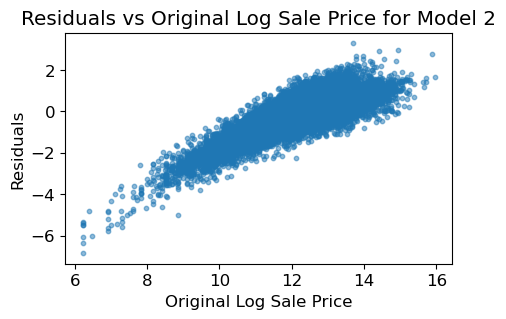![image.png](attachment:image.png)

In [3]:
import numpy as np

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import zipfile
import os

# Plot settings
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 12

### SETUP AND DATA LOADING



In [4]:
with zipfile.ZipFile('data/cook_county_data.zip') as item:
    item.extractall()

In [5]:
initial_data = pd.read_csv("cook_county_train.csv", index_col='Unnamed: 0')

In [6]:
print(f"Dataset shape: {initial_data.shape}")
print(f"Number of features: {initial_data.shape[1]}")

# Quick check of columns
print("\nColumn names:")
print(initial_data.columns.values)

# Look at a sample description
print("\nSample property description:")
print(initial_data['Description'][0])

Dataset shape: (204792, 62)
Number of features: 62

Column names:
['PIN' 'Property Class' 'Neighborhood Code' 'Land Square Feet' 'Town Code'
 'Apartments' 'Wall Material' 'Roof Material' 'Basement' 'Basement Finish'
 'Central Heating' 'Other Heating' 'Central Air' 'Fireplaces' 'Attic Type'
 'Attic Finish' 'Design Plan' 'Cathedral Ceiling' 'Construction Quality'
 'Site Desirability' 'Garage 1 Size' 'Garage 1 Material'
 'Garage 1 Attachment' 'Garage 1 Area' 'Garage 2 Size' 'Garage 2 Material'
 'Garage 2 Attachment' 'Garage 2 Area' 'Porch' 'Other Improvements'
 'Building Square Feet' 'Repair Condition' 'Multi Code'
 'Number of Commercial Units' 'Estimate (Land)' 'Estimate (Building)'
 'Deed No.' 'Sale Price' 'Longitude' 'Latitude' 'Census Tract'
 'Multi Property Indicator' 'Modeling Group' 'Age' 'Use' "O'Hare Noise"
 'Floodplain' 'Road Proximity' 'Sale Year' 'Sale Quarter' 'Sale Half-Year'
 'Sale Quarter of Year' 'Sale Month of Year' 'Sale Half of Year'
 'Most Recent Sale' 'Age Decade' 'P

### PART 1: EDA

In [36]:
def plot_distribution(data, label):
    """
    Creates histogram and boxplot for a variable
    """
    fig, axs = plt.subplots(nrows=2,figsize=(5, 3))
    
    sns.distplot(
        data[label],
        ax=axs[0]
    )
    
    sns.boxplot(
        x=data[label],
        width=0.3,
        ax=axs[1],
        showfliers=False,
    )
    # Align axes
    spacer = np.max(data[label]) * 0.05
    xmin = np.min(data[label]) - spacer
    xmax = np.max(data[label]) + spacer
    axs[0].set_xlim((xmin, xmax))
    axs[1].set_xlim((xmin, xmax))
    
    # Remove some axis text
    axs[0].xaxis.set_visible(False)
    axs[0].yaxis.set_visible(False)
    axs[1].yaxis.set_visible(False)
    
    # Put the two plots together
    plt.subplots_adjust(hspace=0)
    fig.suptitle("Distribution of " + label)
    plt.show()


In [37]:
print(initial_data['Sale Price'].describe())

count    2.047920e+05
mean     2.451646e+05
std      3.628694e+05
min      1.000000e+00
25%      4.520000e+04
50%      1.750000e+05
75%      3.120000e+05
max      7.100000e+07
Name: Sale Price, dtype: float64


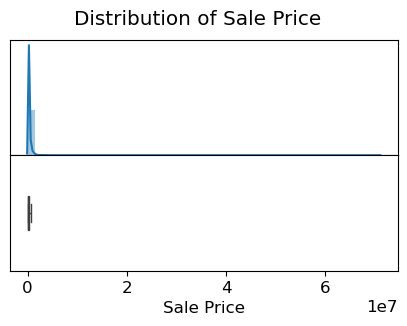

In [38]:
plot_distribution(initial_data, label='Sale Price')

The distribution is heavily right-skewed with a long tail. Median is 175k but mean is 245k due to expensive outliers. Max price is 71 million which seems like a commercial property or data issue.

Therefore, I apply log transformation to normalize the distribution.

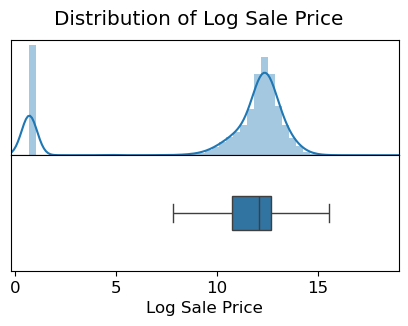


Log Sale Price statistics:
count    204792.000000
mean         10.164665
std           4.444884
min           0.693147
25%          10.718874
50%          12.072547
75%          12.650762
max          18.078190
Name: Log Sale Price, dtype: float64


In [39]:
initial_data['Log Sale Price'] = np.log1p(initial_data['Sale Price'])

plot_distribution(initial_data, label='Log Sale Price')

print("\nLog Sale Price statistics:")
print(initial_data['Log Sale Price'].describe())



Rows after filtering: 168931
Rows removed: 35861


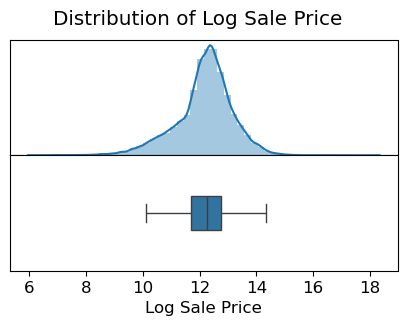

In [40]:
# Filter out suspicious low prices and add log transformation
training_data = initial_data[initial_data['Sale Price'] >= 500].copy()
training_data['Log Sale Price'] = np.log1p(training_data['Sale Price'])

print(f"\nRows after filtering: {training_data.shape[0]}")
print(f"Rows removed: {initial_data.shape[0] - training_data.shape[0]}")

plot_distribution(training_data, label='Log Sale Price')

In [41]:
#Selecting Building Size as an important feature
training_data['Log Building Square Feet'] = np.log1p(training_data['Building Square Feet'])

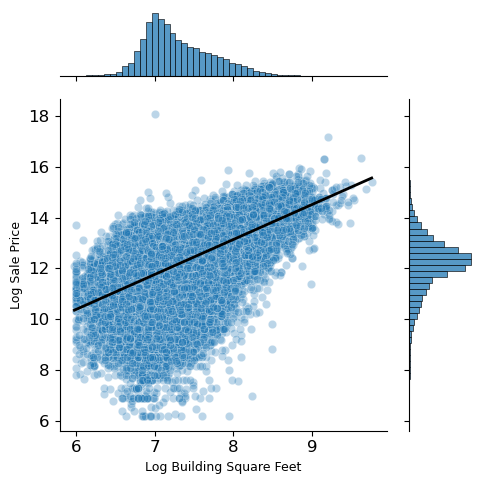

In [35]:
joint = sns.jointplot(
    x='Log Building Square Feet', 
    y='Log Sale Price',
    data=training_data,
    kind='scatter',
    alpha=0.3,
    height=5,
    ratio=4,
    marginal_kws=dict(bins=50, fill=True)
)

joint.plot_joint(sns.regplot, scatter=False, color='black', line_kws=dict(linewidth=2))

joint.set_axis_labels('Log Building Square Feet', 'Log Sale Price', fontsize=9)

plt.tight_layout()
plt.show()


Based on the joint plot showing Log Building Square Feet on the x-axis and Log Sale Price on the y-axis, Log Building Square Feet appears to be a promising candidate as a feature for our model. This is because there is a noticeable positive correlation between Log Building Square Feet and Log Sale Price, as evidenced by the upward trend in the scatter plot and the linear regression line fitted through the data points.

In [15]:
# Removal Function
def remove_outliers(data, variable, lower=-np.inf, upper=np.inf):
    data_copy = data.copy()
    data_filtered = data_copy[(data_copy[variable] >= lower) & 
                              (data_copy[variable] <= upper)]
    return data_filtered

# Test
before = training_data.shape[0]
test_filtered = remove_outliers(training_data, 'Building Square Feet', 
                                lower=500, upper=8000)
after = test_filtered.shape[0]
print(f"Removed: {before - after} outliers")

Removed: 343 outliers


### PART 2: FEATURE ENGINEERING

In [16]:
# Bedrooms
def add_total_bedrooms(data):
    with_rooms = data.copy()
    with_rooms['Bedrooms'] = pd.to_numeric(
        with_rooms['Description']
        .str
        .extract(r"(\d) of which are bedrooms", expand = False)
        .replace(np.nan, "0")
    )
    return with_rooms

training_data = add_total_bedrooms(training_data)

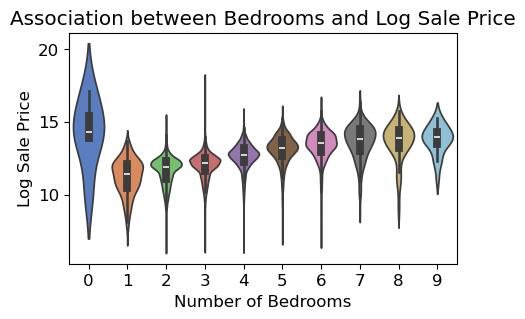

In [18]:
plt.figure(figsize=(5, 3))
sns.violinplot(x='Bedrooms', y='Log Sale Price', data=training_data, palette='muted')


plt.xlabel('Number of Bedrooms')
plt.ylabel('Log Sale Price')
plt.title('Association between Bedrooms and Log Sale Price')
plt.show()

I started by taking a closer look at the 'Description' column and comparing a few sample entries. From this, I found that only a few useful details could be extracted — things like the sale date, number of stories, total rooms, bedrooms, and bathrooms.

To capture one of these features, I wrote a function called 'add_total_bedrooms(data)' that adds a new column, 'Bedrooms', containing the total number of bedrooms for each property (stored as integers). If a value is missing, I simply treat it as zero to keep the data consistent.

In [19]:
# Neighborhoods
num_neighborhoods = training_data['Neighborhood Code'].nunique()
num_neighborhoods

193

In [20]:
top_20_neighborhood_codes = training_data['Neighborhood Code'].value_counts().head(20).index.tolist()

in_top_20_neighborhoods = training_data[training_data['Neighborhood Code'].isin(top_20_neighborhood_codes)]

In [28]:
def plot_categorical(neighborhoods):
    fig, axs = plt.subplots(nrows=2,figsize=(6, 4))

    sns.boxplot(
        x='Neighborhood Code',
        y='Log Sale Price',
        data=neighborhoods,
        ax=axs[0],
    )

    sns.countplot(
        x='Neighborhood Code',
        data=neighborhoods,
        ax=axs[1],
    )

    axs[0].axhline(
        y=training_data['Log Sale Price'].median(), 
        color='red',
        linestyle='dotted'
    )

    for patch in axs[1].patches:
        x = patch.get_bbox().get_points()[:, 0]
        y = patch.get_bbox().get_points()[1, 1]
        axs[1].annotate(f'{int(y)}', (x.mean(), y), ha='center', va='bottom')

    axs[1].set_xticklabels(axs[1].xaxis.get_majorticklabels(), rotation=90)
    axs[0].xaxis.set_visible(False)
    
    plt.subplots_adjust(hspace=0.01)
    plt.show()

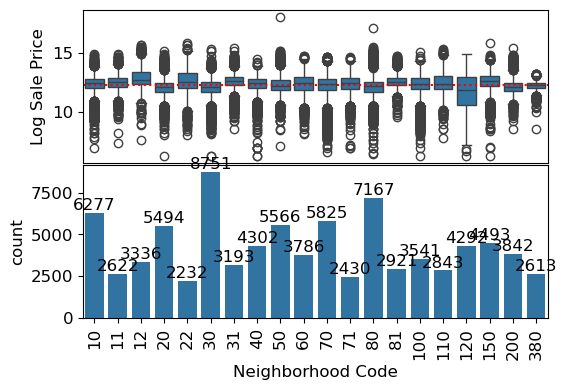

In [29]:
plot_categorical(neighborhoods=in_top_20_neighborhoods)

In [19]:
def find_expensive_neighborhoods(data, n=3, metric=np.median):
    neighborhood_prices = data.groupby('Neighborhood Code')['Log Sale Price'].agg(metric)
    
    neighborhoods = neighborhood_prices.nlargest(n).index
    
    return [int(code) for code in neighborhoods]

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 5, np.median)
expensive_neighborhoods

[44, 94, 93, 106, 580]

In [20]:
def add_in_expensive_neighborhood(data, expensive_neighborhoods):
    data['in_expensive_neighborhood'] = data['Neighborhood Code'].isin(expensive_neighborhoods).astype(int)
    return data

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 3, np.median)
training_data = add_in_expensive_neighborhood(training_data, expensive_neighborhoods)

According to `codebook.txt`, the Assessor's Office uses the following mapping for the numerical values in the `Roof Material` column.
```
Roof Material (Nominal): 

       1    Shingle/Asphalt
       2    Tar & Gravel
       3    Slate
       4    Shake
       5    Tile
       6    Other
```

Therefore, I write a function `substitute_roof_material` that replaces each numerical value in `Roof Material` with their corresponding roof material. 

In [21]:
def substitute_roof_material(data):
    roof_material_mapping = {
        1: 'Shingle/Asphalt',
        2: 'Tar & Gravel',
        3: 'Slate',
        4: 'Shake',
        5: 'Tile',
        6: 'Other'
    }
    
    new_data = data.replace({'Roof Material': roof_material_mapping})
    return new_data
    
training_data_mapped = substitute_roof_material(training_data)
training_data_mapped.head()

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,Basement Finish,...,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size,Log Sale Price,Log Building Square Feet,Bedrooms,in_expensive_neighborhood
1,13272240180000,202,120,3780.0,71,0.0,2.0,Shingle/Asphalt,1.0,1.0,...,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0,12.560248,6.905753,3,0
2,25221150230000,202,210,4375.0,70,0.0,2.0,Shingle/Asphalt,2.0,3.0,...,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0,9.998843,6.811244,3,0
3,10251130030000,203,220,4375.0,17,0.0,3.0,Shingle/Asphalt,1.0,3.0,...,1,1.0,220,17220,"This property, sold on 07/23/2013, is a one-st...",4375.0,12.323860,7.069023,3,0
4,31361040550000,202,120,8400.0,32,0.0,3.0,Shingle/Asphalt,2.0,3.0,...,1,1.0,120,32120,"This property, sold on 06/10/2016, is a one-st...",8400.0,10.025749,6.856462,2,0
6,30314240080000,203,181,10890.0,37,0.0,1.0,Shingle/Asphalt,1.0,3.0,...,1,1.0,181,37181,"This property, sold on 10/26/2017, is a one-st...",10890.0,11.512935,7.458763,4,0


However, I found that simply replacing the integers with the appropriate strings isn’t sufficient for using `Roof Material` in our model.  Since `Roof Material` is a categorical variable, I have to one-hot-encode the data. 

In this way, I create `ohe_roof_material` that returns a `DataFrame` with the new column one-hot-encoded on the roof material of the household. 

In [23]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def ohe_roof_material(data):
    
    encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
    
    roof_material_ohe = encoder.fit_transform(data[['Roof Material']])
    
    roof_material_names = encoder.get_feature_names_out(['Roof Material'])
    
    roof_material_df = pd.DataFrame(roof_material_ohe, columns=roof_material_names)
    
    new_data = pd.concat([data, roof_material_df], axis=1)
    
    return new_data

training_data_ohe = ohe_roof_material(training_data_mapped)
training_data_ohe.filter(regex='^Roof Material_').head(10)

,Roof Material_Other,Roof Material_Shake,Roof Material_Shingle/Asphalt,Roof Material_Slate,Roof Material_Tar & Gravel,Roof Material_Tile
1,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,1.0,0.0,0.0,0.0
8,0.0,0.0,1.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0,0.0,0.0
10,0.0,0.0,1.0,0.0,0.0,0.0
11,0.0,0.0,1.0,0.0,0.0,0.0


### PART 3: Fitting A Simple Model

In [24]:
np.random.seed(1337)

training_val_data = pd.read_csv("cook_county_train.csv", index_col='Unnamed: 0')
def train_val_split(data):
    
    data_len = data.shape[0]
    shuffled_indices = np.random.permutation(data_len)
    split_index = int(0.8 * data_len)
    
    train_indices = shuffled_indices[:split_index]
    validation_indices = shuffled_indices[split_index:]
    
    train = data.iloc[train_indices]
    validation = data.iloc[validation_indices]

   
    return train, validation
train, validation = train_val_split(training_val_data)

In [25]:
def log_transform(data, col):

    data['Log '+col] = np.log(data[col])

    return data 


def feature_engine_simple(data):
    data = remove_outliers(data, 'Sale Price', lower=500)
    data = log_transform(data, 'Sale Price')
    data = add_total_bedrooms(data)
    X = data[['Bedrooms']]
    Y = data['Log Sale Price']
    return X, Y

full_data = pd.read_csv("cook_county_train.csv")

np.random.seed(1337)
train_m1, valid_m1 = train_val_split(full_data)
X_train_m1_simple, Y_train_m1_simple = feature_engine_simple(train_m1)
X_valid_m1_simple, Y_valid_m1_simple = feature_engine_simple(valid_m1)

display(X_train_m1_simple.head())
display(Y_train_m1_simple.head())

,Bedrooms
130829,4
193890,2
30507,2
91308,2
131132,3


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

In [26]:
def feature_engine_pipe(data, pipeline_functions, prediction_col):
    for function, arguments, keyword_arguments in pipeline_functions:
        if keyword_arguments and (not arguments):
            data = data.pipe(function, **keyword_arguments)
        elif (not keyword_arguments) and (arguments):
            data = data.pipe(function, *arguments)
        else:
            data = data.pipe(function)
    X = data.drop(columns=[prediction_col])
    Y = data.loc[:, prediction_col]
    return X, Y

In [27]:
full_data = pd.read_csv("cook_county_train.csv")

np.random.seed(1337)
train_m1, valid_m1 = train_val_split(full_data)

def select_columns(data, *columns):
    return data.loc[:, columns]

m1_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 500,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (add_total_bedrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bedrooms'], None)
]

X_train_m1, Y_train_m1 = feature_engine_pipe(train_m1, m1_pipelines, 'Log Sale Price')
X_valid_m1, Y_valid_m1 = feature_engine_pipe(valid_m1, m1_pipelines, 'Log Sale Price')

display(X_train_m1.head())
display(Y_train_m1.head())

,Bedrooms
130829,4
193890,2
30507,2
91308,2
131132,3


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

In [28]:
np.random.seed(1337)

train_m2, valid_m2 = train_val_split(full_data)

m2_pipelines = [
    (remove_outliers, None, {
        'variable': 'Sale Price',
        'lower': 500,
    }),
    (log_transform, None, {'col': 'Sale Price'}),
    (log_transform, None, {'col': 'Building Square Feet'}),
    (add_total_bedrooms, None, None),
    (select_columns, ['Log Sale Price', 'Bedrooms', 'Log Building Square Feet'], None)
]

X_train_m2, Y_train_m2 = feature_engine_pipe(train_m2, m2_pipelines, 'Log Sale Price')
X_valid_m2, Y_valid_m2 = feature_engine_pipe(valid_m2, m2_pipelines, 'Log Sale Price')


display(X_train_m2.head())
display(Y_train_m2.head())

,Bedrooms,Log Building Square Feet
130829,4,7.870166
193890,2,7.002156
30507,2,6.851185
91308,2,7.228388
131132,3,7.990915


130829    12.994530
193890    11.848683
30507     11.813030
91308     13.060488
131132    12.516861
Name: Log Sale Price, dtype: float64

In [29]:
import sklearn.linear_model as lm
linear_model_m1 = lm.LinearRegression(fit_intercept=True)
linear_model_m2 = lm.LinearRegression(fit_intercept=True)

In [30]:
linear_model_m1.fit(X_train_m1, Y_train_m1)

Y_fitted_m1 = linear_model_m1.predict(X_train_m1)
Y_predicted_m1 = linear_model_m1.predict(X_valid_m1)

linear_model_m2.fit(X_train_m2, Y_train_m2)

Y_fitted_m2 = linear_model_m2.predict(X_train_m2)
Y_predicted_m2 = linear_model_m2.predict(X_valid_m2)

### Part 4: Evaluate My Simple Model

In [31]:
def rmse(predicted, actual):
    return np.sqrt(np.mean((actual - predicted)**2))

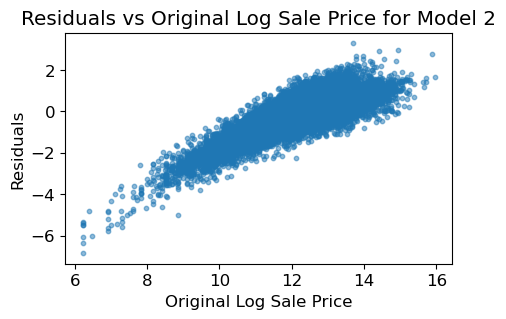

In [43]:
residuals_m2 = Y_valid_m2 - Y_predicted_m2

dot_size = 10
opacity = 0.5

plt.figure(figsize=(5, 3)) 
plt.scatter(Y_valid_m2, residuals_m2, s=dot_size, alpha=opacity)

plt.xlabel('Original Log Sale Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Original Log Sale Price for Model 2')

plt.show()

### Part 6: A More Powerful Model


In [33]:
def add_bathrooms(data):
    
    with_rooms = data.copy()
    with_rooms['Bathrooms'] = pd.to_numeric(
        with_rooms['Description']
        .str
        .extract(r"(\d) of which are bathrooms", expand = False)
        .replace(np.nan, "0")
    )
    return with_rooms

def add_total_rooms(data):
    
    with_rooms = data.copy()
    with_rooms['Rooms'] = pd.to_numeric(
        with_rooms['Description']
        .str
        .extract(r"(\d) of which are rooms", expand = False)
        .replace(np.nan, "0")
    )
    return with_rooms

In [35]:

training_val_data = pd.read_csv("cook_county_train.csv", index_col='Unnamed: 0')
my_train, my_test = train_val_split(training_val_data)

my_train = remove_outliers(my_train, 'Sale Price', lower = 50000, upper = 300000)

my_pipelines = [
    (remove_outliers, ["Sale Price", 500], None),
    (log_transform, ["Sale Price"], None),
    (log_transform, ["Building Square Feet"], None),
    (add_total_bedrooms, None, None),
    (add_bathrooms, None, None),
    (add_total_rooms, None, None),
    (select_columns, ['Log Sale Price', 'Log Building Square Feet', 'Bedrooms', 'Bathrooms', 'Rooms', 'Basement', 'Age', 'Lot Size','Road Proximity','Repair Condition', 'Central Air', 'Design Plan', 'Garage 1 Size'], None)
]

my_X_train, my_y_train = feature_engine_pipe(my_train, my_pipelines, 'Log Sale Price')



my_model = lm.LinearRegression(fit_intercept=True)
my_model.fit(my_X_train, my_y_train)
y_fitted = my_model.predict(my_X_train)

my_rmse = rmse(np.exp(y_fitted), np.exp(my_y_train)) 
my_rmse

67851.23932596862